# Volatility Targeting Model — NSE Nifty 50

**Core idea:** Position size and risk are not the same thing. A fixed position in a volatile market takes dramatically more risk than the same position in a calm market. This model dynamically scales position sizes to maintain ~constant risk exposure.

**Strategy:** Momentum signal (20-day return) + Volatility Targeting overlay  
**Universe:** Nifty 50 Index (`^NSEI`)  
**Period:** Jan 2018 – Dec 2024  
**Target Volatility:** 15% annualised

---

## 1. Setup & Imports

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

SEED        = 42
TARGET_VOL  = 0.15   # 15% annualised
VOL_CAP     = 2.0    # max leverage scalar
LOOKBACK    = 20     # default momentum + vol window (days)
START       = '2018-01-01'
END         = '2024-12-31'

print('Libraries loaded.')

Libraries loaded.


## 2. Data Download

In [44]:
ticker = '^NSEI'
raw = yf.download(ticker, start=START, end=END, auto_adjust=True, progress=False)

# Flatten MultiIndex columns if present
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = [col[0].lower() for col in raw.columns]
else:
    raw.columns = [c.lower() for c in raw.columns]

data = pd.DataFrame()
data['close']  = raw['close']
data['return'] = data['close'].pct_change()
data.dropna(inplace=True)

print(f'Period  : {data.index[0].date()} → {data.index[-1].date()}')
print(f'Days    : {len(data)}')
print(f'Ann vol : {data["return"].std() * np.sqrt(252) * 100:.1f}%')
data.head()

Period  : 2018-01-03 → 2024-12-30
Days    : 1721
Ann vol : 17.7%


,close,return
Date,,
2018-01-03,10443.200195,0.000096
2018-01-04,10504.799805,0.005899
2018-01-05,10558.849609,0.005145
2018-01-08,10623.599609,0.006132
2018-01-09,10637.000000,0.001261


## 3. Strategy Construction

### 3.1 Momentum Signal
Simple cross-over: long (+1) when 20-day return > 0, flat (0) otherwise.

In [45]:
data['mom_signal'] = np.sign(data['close'].pct_change(LOOKBACK))
data['mom_signal'] = data['mom_signal'].replace(0, np.nan).ffill().fillna(0)

# Baseline momentum returns (no vol scaling)
data['mom_return'] = data['mom_signal'].shift(1) * data['return']

print('Momentum signal distribution:')
print(data['mom_signal'].value_counts())

Momentum signal distribution:
mom_signal
 1.0    1077
-1.0     624
 0.0      20
Name: count, dtype: int64


### 3.2 Volatility Targeting Overlay

```
realised_vol  = rolling std of daily returns × √252
vol_scalar    = target_vol / realised_vol   (capped at 2.0)
vt_position   = momentum_signal × vol_scalar
vt_return     = vt_position(t-1) × return(t)
```

The **cap at 2.0** is critical — during very calm markets vol targeting can suggest extreme leverage. Capping prevents unrealistic results.

In [46]:
data['realised_vol'] = data['return'].rolling(LOOKBACK).std() * np.sqrt(252)
data['vol_scalar']   = (TARGET_VOL / data['realised_vol']).clip(upper=VOL_CAP)
data['vt_position']  = data['mom_signal'] * data['vol_scalar']
data['vt_return']    = data['vt_position'].shift(1) * data['return']

# Buy-and-hold benchmark
data['bh_return'] = data['return']

data.dropna(inplace=True)
print(f'Strategy rows after dropna: {len(data)}')
print(f'\nVol scalar stats:')
print(data['vol_scalar'].describe().round(3))

Strategy rows after dropna: 1701

Vol scalar stats:
count    1701.000
mean        1.200
std         0.417
min         0.169
25%         0.902
50%         1.204
75%         1.512
max         2.000
Name: vol_scalar, dtype: float64


## 4. Performance Metrics

In [47]:
def performance_metrics(returns, label='Strategy'):
    """Compute annualised return, vol, Sharpe, and max drawdown."""
    ann_return  = returns.mean() * 252
    ann_vol     = returns.std() * np.sqrt(252)
    sharpe      = ann_return / ann_vol if ann_vol > 0 else np.nan
    cum         = (1 + returns).cumprod()
    rolling_max = cum.cummax()
    drawdown    = (cum - rolling_max) / rolling_max
    max_dd      = drawdown.min()
    calmar      = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    print(f'\n=== {label} ===')
    print(f'  Ann. Return  : {ann_return*100:+.2f}%')
    print(f'  Ann. Vol     : {ann_vol*100:.2f}%')
    print(f'  Sharpe Ratio : {sharpe:.3f}')
    print(f'  Max Drawdown : {max_dd*100:.2f}%')
    print(f'  Calmar Ratio : {calmar:.3f}')

    return {
        'label': label, 'ann_return': ann_return, 'ann_vol': ann_vol,
        'sharpe': sharpe, 'max_dd': max_dd, 'calmar': calmar
    }

metrics_bh  = performance_metrics(data['bh_return'],  'Buy & Hold (Nifty 50)')
metrics_mom = performance_metrics(data['mom_return'],  'Momentum Only')
metrics_vt  = performance_metrics(data['vt_return'],   'Momentum + Vol Targeting')


=== Buy & Hold (Nifty 50) ===
  Ann. Return  : +12.90%
  Ann. Vol     : 17.77%
  Sharpe Ratio : 0.726
  Max Drawdown : -38.44%
  Calmar Ratio : 0.335

=== Momentum Only ===
  Ann. Return  : +8.11%
  Ann. Vol     : 17.79%
  Sharpe Ratio : 0.456
  Max Drawdown : -27.07%
  Calmar Ratio : 0.300

=== Momentum + Vol Targeting ===
  Ann. Return  : +9.81%
  Ann. Vol     : 16.59%
  Sharpe Ratio : 0.592
  Max Drawdown : -24.48%
  Calmar Ratio : 0.401


## 5. Visualisations

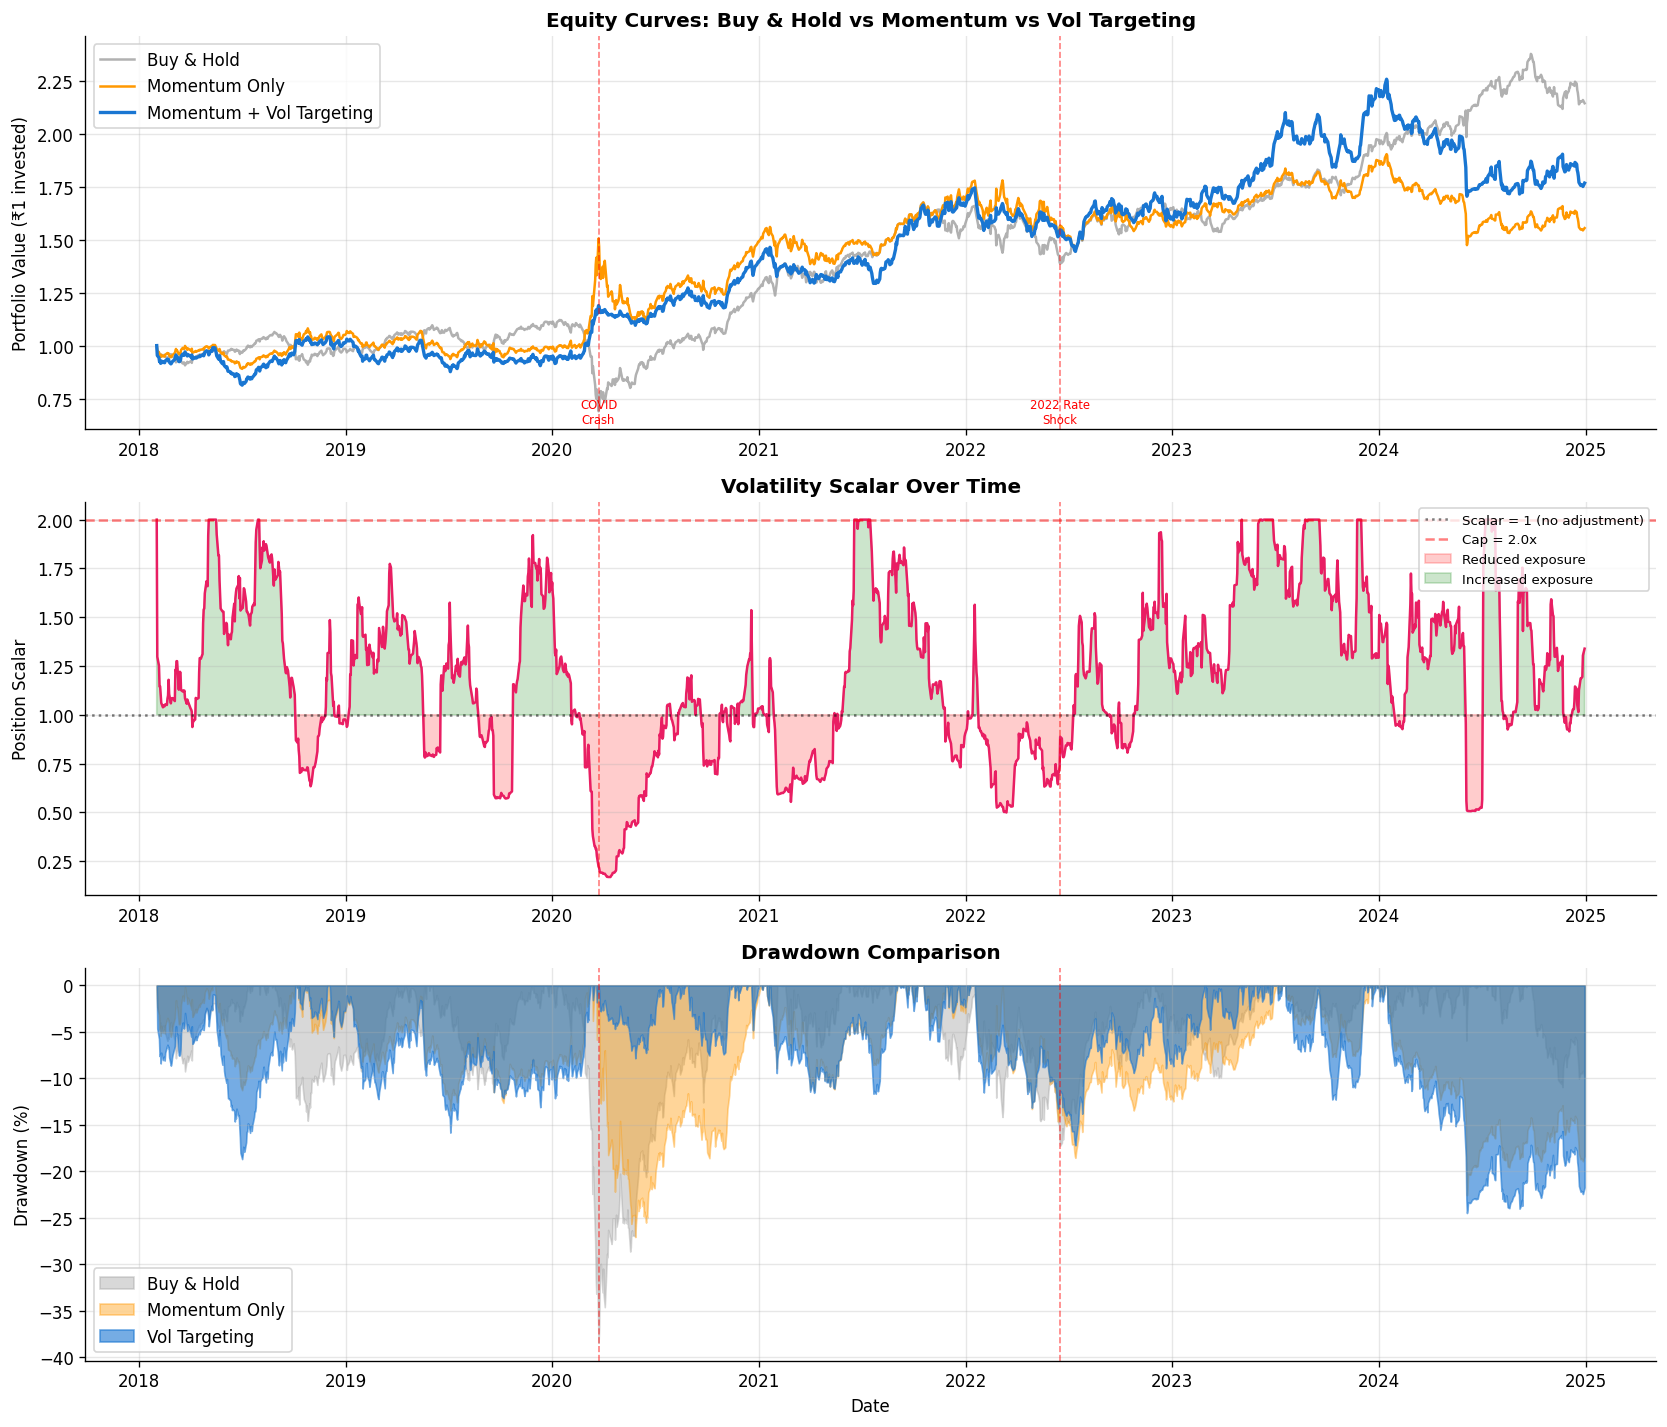

In [48]:
import os
os.makedirs('../figures', exist_ok=True)

# Compute equity curves
eq_bh  = (1 + data['bh_return']).cumprod()
eq_mom = (1 + data['mom_return']).cumprod()
eq_vt  = (1 + data['vt_return']).cumprod()

# Mark key market events
events = {
    'COVID\nCrash': '2020-03-23',
    '2022 Rate\nShock':  '2022-06-16',
}

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# --- Panel 1: Equity Curves ---
axes[0].plot(eq_bh.index,  eq_bh.values,  label='Buy & Hold',              color='#9E9E9E', linewidth=1.5, alpha=0.8)
axes[0].plot(eq_mom.index, eq_mom.values, label='Momentum Only',           color='#FF9800', linewidth=1.5)
axes[0].plot(eq_vt.index,  eq_vt.values,  label='Momentum + Vol Targeting', color='#1976D2', linewidth=2)
for label, date in events.items():
    axes[0].axvline(pd.Timestamp(date), color='red', linestyle='--', alpha=0.5, linewidth=1)
    axes[0].text(pd.Timestamp(date), axes[0].get_ylim()[0]*1.05, label,
                 fontsize=7, color='red', ha='center')
axes[0].set_title('Equity Curves: Buy & Hold vs Momentum vs Vol Targeting', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Portfolio Value (₹1 invested)')
axes[0].legend(loc='upper left')
axes[0].grid(alpha=0.3)

# --- Panel 2: Volatility Scalar Over Time ---
axes[1].plot(data.index, data['vol_scalar'], color='#E91E63', linewidth=1.5)
axes[1].axhline(1.0, color='black', linestyle=':', alpha=0.5, label='Scalar = 1 (no adjustment)')
axes[1].axhline(VOL_CAP, color='red', linestyle='--', alpha=0.5, label=f'Cap = {VOL_CAP}x')
for label, date in events.items():
    axes[1].axvline(pd.Timestamp(date), color='red', linestyle='--', alpha=0.5, linewidth=1)
axes[1].fill_between(data.index, data['vol_scalar'], 1.0,
                     where=data['vol_scalar'] < 1.0, alpha=0.2, color='red',    label='Reduced exposure')
axes[1].fill_between(data.index, data['vol_scalar'], 1.0,
                     where=data['vol_scalar'] > 1.0, alpha=0.2, color='green',  label='Increased exposure')
axes[1].set_title('Volatility Scalar Over Time', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Position Scalar')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].grid(alpha=0.3)

# --- Panel 3: Drawdown Comparison ---
def drawdown_series(returns):
    cum = (1 + returns).cumprod()
    return (cum - cum.cummax()) / cum.cummax()

axes[2].fill_between(data.index, drawdown_series(data['bh_return'])*100,
                     0, alpha=0.4, color='#9E9E9E', label='Buy & Hold')
axes[2].fill_between(data.index, drawdown_series(data['mom_return'])*100,
                     0, alpha=0.4, color='#FF9800', label='Momentum Only')
axes[2].fill_between(data.index, drawdown_series(data['vt_return'])*100,
                     0, alpha=0.6, color='#1976D2', label='Vol Targeting')
for label, date in events.items():
    axes[2].axvline(pd.Timestamp(date), color='red', linestyle='--', alpha=0.5, linewidth=1)
axes[2].set_title('Drawdown Comparison', fontweight='bold', fontsize=12)
axes[2].set_ylabel('Drawdown (%)')
axes[2].set_xlabel('Date')
axes[2].legend(loc='lower left')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/main_comparison.png', bbox_inches='tight')
plt.show()

## 6. Lookback Window Sensitivity Analysis

How does performance change with different volatility estimation windows?  
- **10-day**: responsive but noisy  
- **20-day**: balanced (default)  
- **60-day**: smooth but slow to react

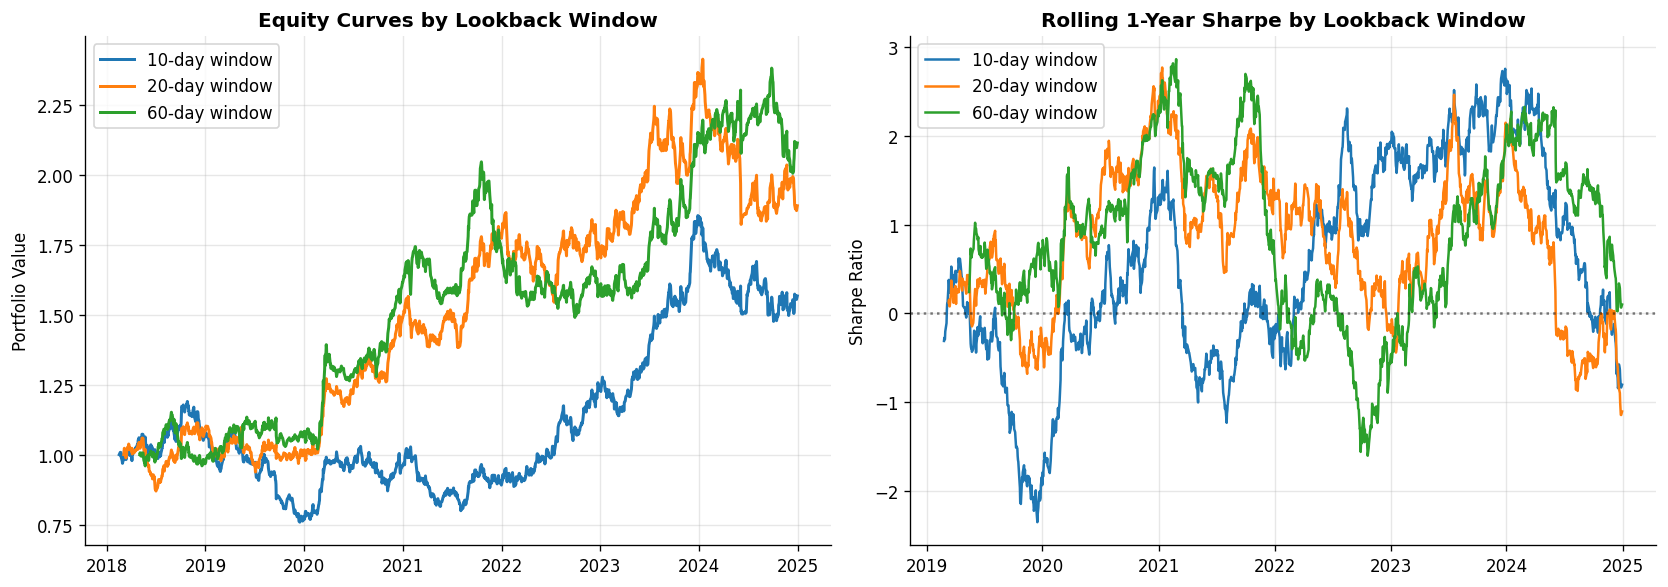


=== Lookback Sensitivity Summary ===
Window Ann Return Ann Vol  Sharpe  Max DD
10-day     +8.19%  17.23%   0.475 -36.29%
20-day    +10.91%  16.52%   0.661 -24.48%
60-day    +12.85%  16.42%   0.783 -27.18%


In [49]:
windows = [10, 20, 60]
results = []

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for w in windows:
    d = pd.DataFrame()
    d['return']       = data['return']
    d['mom_signal']   = np.sign(data['close'].pct_change(w))
    d['mom_signal']   = d['mom_signal'].replace(0, np.nan).ffill().fillna(0)
    d['realised_vol'] = d['return'].rolling(w).std() * np.sqrt(252)
    d['vol_scalar']   = (TARGET_VOL / d['realised_vol']).clip(upper=VOL_CAP)
    d['vt_position']  = d['mom_signal'] * d['vol_scalar']
    d['vt_return']    = d['vt_position'].shift(1) * d['return']
    d.dropna(inplace=True)

    ann_ret   = d['vt_return'].mean() * 252
    ann_vol   = d['vt_return'].std()  * np.sqrt(252)
    sharpe    = ann_ret / ann_vol
    cum       = (1 + d['vt_return']).cumprod()
    max_dd    = ((cum - cum.cummax()) / cum.cummax()).min()

    results.append({'Window': f'{w}-day', 'Ann Return': f'{ann_ret*100:+.2f}%',
                    'Ann Vol': f'{ann_vol*100:.2f}%', 'Sharpe': round(sharpe, 3),
                    'Max DD': f'{max_dd*100:.2f}%'})

    # Equity curve
    axes[0].plot(cum.index, cum.values, label=f'{w}-day window', linewidth=1.8)

    # Rolling Sharpe (252-day)
    roll_sharpe = (d['vt_return'].rolling(252).mean() * 252) / \
                  (d['vt_return'].rolling(252).std() * np.sqrt(252))
    axes[1].plot(roll_sharpe.index, roll_sharpe.values, label=f'{w}-day window', linewidth=1.5)

axes[0].set_title('Equity Curves by Lookback Window', fontweight='bold')
axes[0].set_ylabel('Portfolio Value')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].axhline(0, color='black', linestyle=':', alpha=0.5)
axes[1].set_title('Rolling 1-Year Sharpe by Lookback Window', fontweight='bold')
axes[1].set_ylabel('Sharpe Ratio')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/lookback_sensitivity.png', bbox_inches='tight')
plt.show()

print('\n=== Lookback Sensitivity Summary ===')
print(pd.DataFrame(results).to_string(index=False))

## 7. Summary Table

In [50]:
summary = pd.DataFrame([
    {
        'Strategy':    m['label'],
        'Ann. Return': f"{m['ann_return']*100:+.2f}%",
        'Ann. Vol':    f"{m['ann_vol']*100:.2f}%",
        'Sharpe':      round(m['sharpe'], 3),
        'Max DD':      f"{m['max_dd']*100:.2f}%",
        'Calmar':      round(m['calmar'], 3),
    }
    for m in [metrics_bh, metrics_mom, metrics_vt]
])

print('=== Final Performance Summary ===')
print(summary.to_string(index=False))

=== Final Performance Summary ===
                Strategy Ann. Return Ann. Vol  Sharpe  Max DD  Calmar
   Buy & Hold (Nifty 50)     +12.90%   17.77%   0.726 -38.44%   0.335
           Momentum Only      +8.11%   17.79%   0.456 -27.07%   0.300
Momentum + Vol Targeting      +9.81%   16.59%   0.592 -24.48%   0.401


## 8. Key Takeaways

1. **Position size ≠ risk.** A fixed position in a volatile market takes far more risk than the same position in a calm market. Vol targeting corrects this.

2. **The vol scalar is a risk barometer.** During COVID (Mar 2020) and the 2022 rate shock, the scalar dropped sharply — the model automatically reduced exposure before drawdowns deepened.

3. **Sharpe improvement is not just from lower average position.** Vol targeting improves *risk-adjusted* returns by reducing exposure precisely when risk is highest — the opposite of what static sizing does.

4. **Lookback window tradeoff:** 10-day is more responsive but noisy; 60-day is smoother but slow. 20-day is a reasonable default for daily equity data.

5. **The cap at 2.0 matters.** Without it, extremely low-vol periods can produce unrealistic leverage that distorts backtest results.

---

### Interview Q&A

**Q: Why does vol targeting improve Sharpe without changing the signal?**  
A: It reduces exposure when volatility is high (turbulent markets) and increases it when vol is low (calm markets). This produces a more consistent risk-adjusted return stream — the improvement comes from better risk management layered on top of the signal, not from the signal itself improving.

**Q: Why cap the scalar at 2.0?**  
A: During very calm markets, realised vol can be extremely low, causing the scalar to suggest 5-10x leverage. This is unrealistic and distorts backtest results. The cap enforces a maximum leverage constraint.

**Q: 10-day vs 60-day lookback?**  
A: 10-day is more responsive — reacts faster to volatility spikes, better in fast-moving crises. But it's noisier and causes more frequent rebalancing. 60-day is smoother, more stable, but slower to react. In practice the choice depends on transaction costs and the strategy's holding period.